**Trader Performance vs Market Sentiment**

**OBJECTIVE**


```
## Analyze how market sentiment (Fear/Greed)
relates to trader behavior and performance
on Hyperliquid. Your goal is to uncover
patterns that could inform smarter trading strategies.






**Import Libraries**

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Import Datasets**

In [7]:
sentiment = pd.read_csv("fear_greed_index.csv")
trades = pd.read_csv("historical_data.csv")

**# Part A — Data Preparation**

In [8]:
# Function to summarize dataset
def dataset_summary(df, name):
    print("="*50)
    print(f"Dataset Name : {name}")
    print("="*50)

    # Rows and Columns
    print("Rows, Columns :", df.shape)

    # Column names
    print("\nColumns:")
    print(df.columns.tolist())

    # Missing Values
    print("\nMissing Values:")
    print(df.isnull().sum())

    # Duplicate Rows
    print("\nDuplicate Rows :", df.duplicated().sum())

    print("\nFirst 5 Rows:")
    print(df.head())
    print("\n")


# Apply function
dataset_summary(sentiment, "Bitcoin Market Sentiment")
dataset_summary(trades, "Historical Trader Data")

Dataset Name : Bitcoin Market Sentiment
Rows, Columns : (2644, 4)

Columns:
['timestamp', 'value', 'classification', 'date']

Missing Values:
timestamp         0
value             0
classification    0
date              0
dtype: int64

Duplicate Rows : 0

First 5 Rows:
    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05


Dataset Name : Historical Trader Data
Rows, Columns : (211224, 16)

Columns:
['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']

Missing Values:
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Tim

**Convert timestamps and align the datasets by date (daily level is fine)**

In [9]:
sentiment['date'] = pd.to_datetime(sentiment['date'])

In [10]:
## Daily Date
sentiment['date'] = sentiment['date'].dt.floor('D')

In [11]:
trades['Timestamp IST'] = pd.to_datetime(
    trades['Timestamp IST'],
    format='%d-%m-%Y %H:%M',
    errors='coerce'
)

In [12]:
trades['date'] = trades['Timestamp IST'].dt.floor('D')

In [13]:
## Merge the Datasets
data = pd.merge(trades,sentiment,on='date',how='left')

In [14]:
data.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,timestamp,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed


In [15]:
data.columns = data.columns.str.lower().str.replace(' ','',regex=True)
## I convert all the columns into lower and remove space.

# **Create the key metrics you will analyze, for example:
1. daily PnL per trader (or per account)
2. win rate, average trade size
3. leverage distribution
4. number of trades per day
5. long/short ratio
**

In [16]:
## Daily PNL per Account
daily_pnl = data.groupby(['date','account'])['closedpnl'].sum().reset_index().sort_values(by='closedpnl',ascending=False)
daily_pnl

,date,account,closedpnl
1561,2025-03-03,0x083384f897ee0f19899168e3b1bec365f52a9012,533974.662903
712,2024-12-12,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,449328.107544
1246,2025-02-04,0x083384f897ee0f19899168e3b1bec365f52a9012,375620.270243
834,2024-12-22,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,327545.999992
2074,2025-04-12,0x083384f897ee0f19899168e3b1bec365f52a9012,307855.803410
...,...,...,...
354,2024-08-04,0x4f93fead39b70a1824f981a54d4e55b278e9f760,-108604.496278
2339,2025-05-01,0xbd5fead7180a9c139fa51a103cb6a2ce86ddb5c3,-113601.020138
582,2024-11-28,0x083384f897ee0f19899168e3b1bec365f52a9012,-132271.000000
646,2024-12-06,0x083384f897ee0f19899168e3b1bec365f52a9012,-175611.000056


In [17]:
## Win Rate Per Account
data['win_flag'] = (data['closedpnl']>0).astype(int)

In [18]:
win_rate = (data.groupby(['account'])['win_flag'].mean().reset_index(name='Win_Rate'))*100
win_rate.head()

,account,Win_Rate
0,0x083384f897ee0f19899168e3b1bec365f52a90120x08...,35.961236
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd0x23...,44.271978
2,0x271b280974205ca63b716753467d5a371de622ab0x27...,30.191651
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c40x28...,43.858463
4,0x2c229d22b100a7beb69122eed721cee9b24011dd0x2c...,51.991355


In [19]:
## Average Trade Size
average_trade_size = data.groupby('account')['sizeusd'].mean().reset_index(name='Avg_Trade_Size_USD')
average_trade_size.head()

,account,Avg_Trade_Size_USD
0,0x083384f897ee0f19899168e3b1bec365f52a9012,16159.576734
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,1653.226327
2,0x271b280974205ca63b716753467d5a371de622ab,8893.000898
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,507.626933
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3138.894782


In [20]:
## Trade Per Day
trades_per_day = data.groupby('date').size().reset_index(name='Trade_Count').sort_values(by='Trade_Count',ascending=False)
trades_per_day.head()

,date,Trade_Count
414,2025-02-25,6246
471,2025-04-23,6159
413,2025-02-24,5616
429,2025-03-12,3968
457,2025-04-09,3967


In [21]:
# Long / Short ratio
long_count = trades['Side'].str.lower().eq('buy').sum()
short_count = trades['Side'].str.lower().eq('sell').sum()

In [22]:
long_short_ratio = long_count / short_count
long_short_ratio

np.float64(0.9462627156125608)

**Part B — Analysis**

*1. Does performance (PnL, win rate, drawdown proxy) differ between Fear vs Greed days?*

In [23]:
## 1. Trade-Level Performance
performance_summary = data.groupby('classification').agg(
    Total_PnL=('closedpnl','sum'),
    Avg_PnL=('closedpnl','mean'),
    Median_PnL=('closedpnl','median'),
    Win_Rate=('win_flag', lambda x: round(x.mean()*100,2)),
    Trades=('closedpnl','count')
).reset_index()

performance_summary

,classification,Total_PnL,Avg_PnL,Median_PnL,Win_Rate,Trades
0,Extreme Fear,7.391102e+05,34.537862,0.0,37.06,21400
1,Extreme Greed,2.715171e+06,67.892861,0.0,46.49,39992
2,Fear,3.357155e+06,54.290400,0.0,42.08,61837
3,Greed,2.150129e+06,42.743559,0.0,38.48,50303
4,Neutral,1.292921e+06,34.307718,0.0,39.70,37686


In [24]:
## 2. Daily Performance
daily_perfor = data.groupby(['date','classification'])['closedpnl'].sum().reset_index()

daily_summary = daily_perfor.groupby('classification').agg(
    Avg_Daily_PnL=('closedpnl','mean'),
    Median_Daily_PnL=('closedpnl','median'),
    Best_Day=('closedpnl','max'),
    Worst_Day=('closedpnl','min')
).reset_index()

daily_summary


,classification,Avg_Daily_PnL,Median_Daily_PnL,Best_Day,Worst_Day
0,Extreme Fear,52793.589178,22561.739636,269328.365917,-76880.729036
1,Extreme Greed,23817.292199,3127.536297,599151.795008,-127075.399585
2,Fear,36891.818040,1412.314654,616413.032233,-122672.000883
3,Greed,11140.566181,678.475928,416876.888120,-419020.225731
4,Neutral,19297.323516,1818.573295,213860.675308,-10116.875552


In [25]:
## 3. Drawdown Proxy Avg losses on losing days
drawdown = daily_perfor.groupby('classification')['closedpnl'].apply(
    lambda x: x[x < 0].mean()
).reset_index(name='Avg_Loss_On_Losing_Days')

drawdown


,classification,Avg_Loss_On_Losing_Days
0,Extreme Fear,-24912.298561
1,Extreme Greed,-19978.844479
2,Fear,-21773.615605
3,Greed,-23194.461526
4,Neutral,-2637.163692


**2. Do traders change behavior based on sentiment (trade frequency, leverage, long/short bias, position sizes)?**

In [26]:
data['leverage'] = data['sizeusd'] / data['startposition'].replace(0,pd.NA)

In [27]:
## Trade Frequency
trade_freq = data.groupby('classification').agg(
    Total_Trades = ('account','count'),
    Active_Days = ('date','nunique')
).reset_index()

trade_freq['Avg_Trades_Per_Day'] = trade_freq['Total_Trades'] / trade_freq['Active_Days']
trade_freq

,classification,Total_Trades,Active_Days,Avg_Trades_Per_Day
0,Extreme Fear,21400,14,1528.571429
1,Extreme Greed,39992,114,350.807018
2,Fear,61837,91,679.527473
3,Greed,50303,193,260.637306
4,Neutral,37686,67,562.477612


In [28]:
##  Avg Leverage
leverage_stats = data.groupby('classification')['leverage'].mean().reset_index(name = 'Avg_Leverae')
leverage_stats

,classification,Avg_Leverae
0,Extreme Fear,47176.007298
1,Extreme Greed,-935.939858
2,Fear,92673.599748
3,Greed,743525.940018
4,Neutral,2317379.449264


In [29]:
## Position size
position_size = data.groupby('classification')['sizeusd'].mean().reset_index(name='Avg_Position_Size_USD')
position_size

,classification,Avg_Position_Size_USD
0,Extreme Fear,5349.731843
1,Extreme Greed,3112.251565
2,Fear,7816.109931
3,Greed,5736.884375
4,Neutral,4782.732661


In [30]:
## Long short bias
long_short = pd.crosstab(data['classification'],data['side'])
long_short

side,BUY,SELL
classification,,
Extreme Fear,10935,10465
Extreme Greed,17940,22052
Fear,30270,31567
Greed,24576,25727
Neutral,18969,18717


##**3. Identify 2–3 segments (examples):
1. high leverage vs low leverage traders
2. frequent vs infrequent traders
3. consistent winners vs inconsistent traders
**

In [31]:
## Account Leverage Summary
segments = data.groupby('account').agg(
    Total_Trades=('account','size'),
    Avg_Leverage=('leverage','mean'),
    Win_Rate=('closedpnl', lambda x: (x > 0).mean()*100),
    Avg_PnL=('closedpnl','mean'),
    PnL_STD=('closedpnl','std')
).reset_index()


In [32]:
# 1. High vs Low Leverage
lev_median = segments['Avg_Leverage'].median()
segments['Leverae_Segment'] = segments['Avg_Leverage'].apply(lambda x: 'High_Leverage' if x>= lev_median else 'Low Leverage')
segments.head()

,account,Total_Trades,Avg_Leverage,Win_Rate,Avg_PnL,PnL_STD,Leverae_Segment
0,0x083384f897ee0f19899168e3b1bec365f52a9012,3818,-56.528045,35.961236,419.127768,4692.452329,Low Leverage
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,7280,234004.140959,44.271978,6.577654,134.073473,High_Leverage
2,0x271b280974205ca63b716753467d5a371de622ab,3809,-5470.65149,30.191651,-18.492043,542.182659,Low Leverage
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,13311,895.519175,43.858463,9.951530,113.269353,Low Leverage
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3239,21.747341,51.991355,52.071011,255.829091,Low Leverage


In [33]:
# 2. Frequent vs Infrequent
trade_median = segments['Total_Trades'].median()
segments['Frequency_Segment'] = segments['Total_Trades'].apply(lambda x: 'Frequency' if x>= trade_median else 'Infrequency')
segments.head()

,account,Total_Trades,Avg_Leverage,Win_Rate,Avg_PnL,PnL_STD,Leverae_Segment,Frequency_Segment
0,0x083384f897ee0f19899168e3b1bec365f52a9012,3818,-56.528045,35.961236,419.127768,4692.452329,Low Leverage,Frequency
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,7280,234004.140959,44.271978,6.577654,134.073473,High_Leverage,Frequency
2,0x271b280974205ca63b716753467d5a371de622ab,3809,-5470.65149,30.191651,-18.492043,542.182659,Low Leverage,Frequency
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,13311,895.519175,43.858463,9.951530,113.269353,Low Leverage,Frequency
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3239,21.747341,51.991355,52.071011,255.829091,Low Leverage,Infrequency


In [34]:
# 3. Consistent Winners vs Inconsistent
pnl_std_cutoff = segments['PnL_STD'].median()

segments['Winner_Segment'] = segments.apply(
    lambda x: 'Consistent Winner'
    if (x['Win_Rate'] >= 55) and (x['PnL_STD'] <= pnl_std_cutoff)
    else 'Inconsistent',
    axis=1
)

pnl_std_cutoff

550.4807059586997

In [36]:
data. info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 22 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   account          211224 non-null  object        
 1   coin             211224 non-null  object        
 2   executionprice   211224 non-null  float64       
 3   sizetokens       211224 non-null  float64       
 4   sizeusd          211224 non-null  float64       
 5   side             211224 non-null  object        
 6   timestampist     211224 non-null  datetime64[ns]
 7   startposition    211224 non-null  float64       
 8   direction        211224 non-null  object        
 9   closedpnl        211224 non-null  float64       
 10  transactionhash  211224 non-null  object        
 11  orderid          211224 non-null  int64         
 12  crossed          211224 non-null  bool          
 13  fee              211224 non-null  float64       
 14  tradeid          211

**Provide charts**

  classification    Avg_PnL     Total_PnL  Win_Rate      Avg_Loss
0   Extreme Fear  34.537862  7.391102e+05  0.370607  -31036.69194
1  Extreme Greed  67.892861  2.715171e+06  0.464943  -10259.46800
2           Fear  54.290400  3.357155e+06  0.420768  -35681.74723
3          Greed  42.743559  2.150129e+06  0.384828 -117990.10410
4        Neutral  34.307718  1.292921e+06  0.396991  -24500.00000


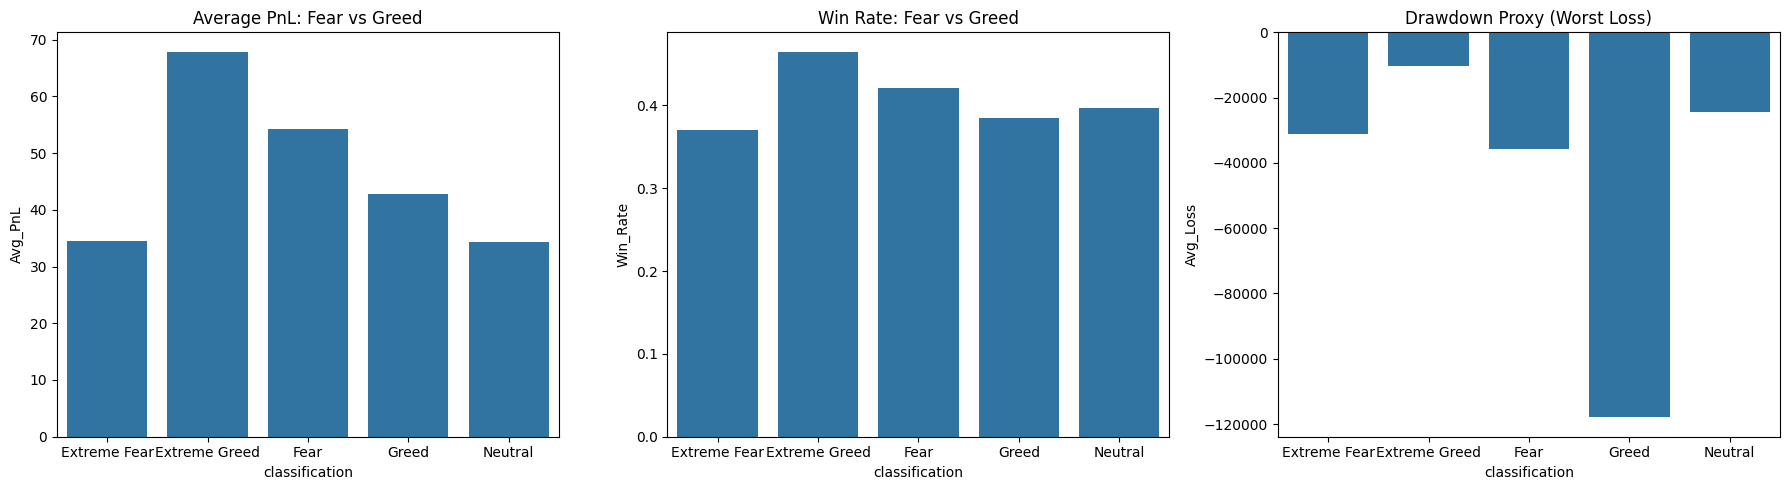

In [38]:
## 1. PERFORMANCE: Fear vs Greed


perf = data.groupby('classification').agg(
    Avg_PnL=('closedpnl','mean'),
    Total_PnL=('closedpnl','sum'),
    Win_Rate=('win_flag','mean'),
    Avg_Loss=('closedpnl','min')
).reset_index()

print(perf)

fig, ax = plt.subplots(1,3, figsize=(18,5))

sns.barplot(data=perf, x='classification', y='Avg_PnL', ax=ax[0])
ax[0].set_title("Average PnL: Fear vs Greed")

sns.barplot(data=perf, x='classification', y='Win_Rate', ax=ax[1])
ax[1].set_title("Win Rate: Fear vs Greed")

sns.barplot(data=perf, x='classification', y='Avg_Loss', ax=ax[2])
ax[2].set_title("Drawdown Proxy (Worst Loss)")

plt.tight_layout()
plt.show()


  classification  Trade_Count    Avg_Leverage  Avg_Position
0   Extreme Fear        21400    47176.007298   5349.731843
1  Extreme Greed        39992     -935.939858   3112.251565
2           Fear        61837    92673.599748   7816.109931
3          Greed        50303   743525.940018   5736.884375
4        Neutral        37686  2317379.449264   4782.732661


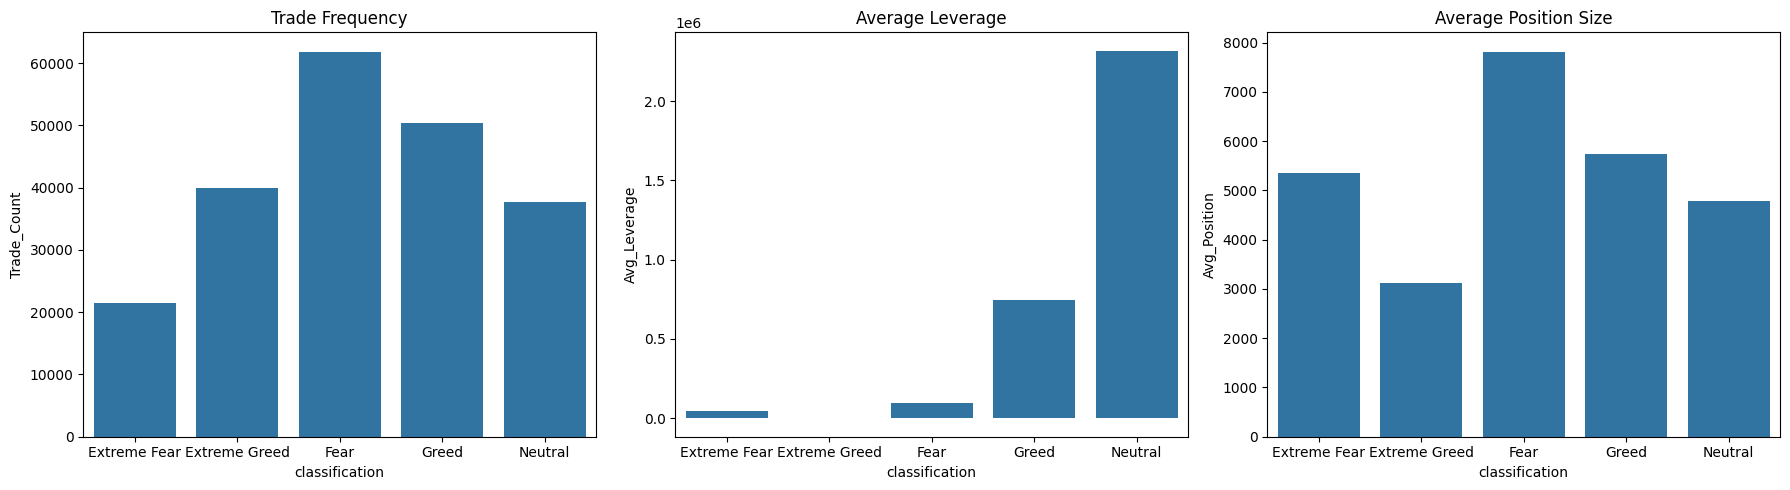

In [40]:
# 2. TRADER BEHAVIOR CHANGE BY SENTIMENT

behavior = data.groupby('classification').agg(
    Trade_Count=('tradeid','count'),
    Avg_Leverage=('leverage','mean'),
    Avg_Position=('sizeusd','mean')
).reset_index()

print(behavior)

fig, ax = plt.subplots(1,3, figsize=(18,5))

sns.barplot(data=behavior, x='classification', y='Trade_Count', ax=ax[0])
ax[0].set_title("Trade Frequency")

sns.barplot(data=behavior, x='classification', y='Avg_Leverage', ax=ax[1])
ax[1].set_title("Average Leverage")

sns.barplot(data=behavior, x='classification', y='Avg_Position', ax=ax[2])
ax[2].set_title("Average Position Size")

plt.tight_layout()
plt.show()

direction       Auto-Deleveraging   Buy  Close Long  Close Short  \
classification                                                     
Extreme Fear                    0   807        6241         3117   
Extreme Greed                   0  5132        7186         6497   
Fear                            0  3207       17260         9221   
Greed                           8  4685        7998        11322   
Neutral                         0  2885        9993         5850   

direction       Liquidated Isolated Short  Long > Short  Open Long  \
classification                                                       
Extreme Fear                            0             5       7005   
Extreme Greed                           0             7       6300   
Fear                                    0            14      17824   
Greed                                   1            16       8544   
Neutral                                 0            15      10222   

direction       Open Short  Sell

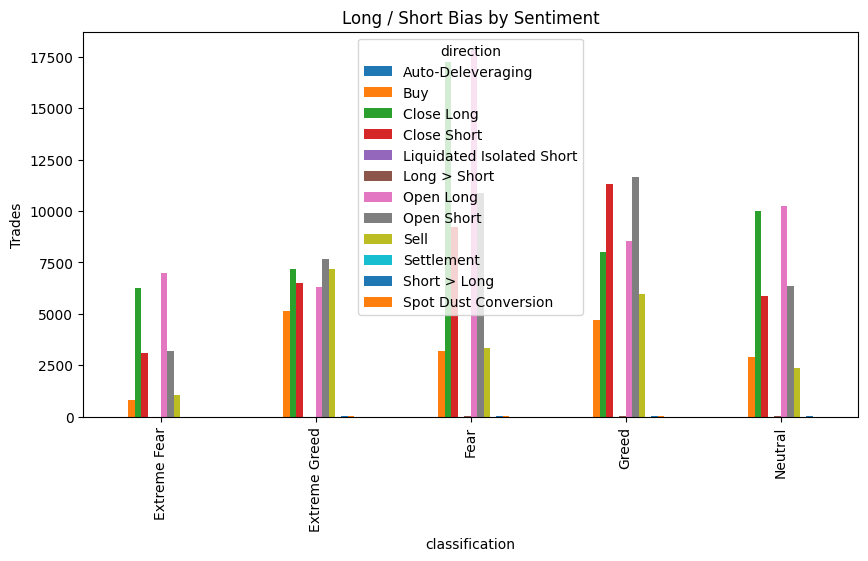

In [42]:
#  Long / Short Bias
bias = pd.crosstab(data['classification'], data['direction'])
print(bias)

bias.plot(kind='bar', figsize=(10,5))
plt.title("Long / Short Bias by Sentiment")
plt.ylabel("Trades")
plt.show()


**Part C**

**Actionable output**
1. Propose 2 strategy ideas or “rules of thumb” based on your findings.
Example: “During Fear days, reduce leverage for segment X; increase trade frequency only for segment Y.



```
Strategy 1 — Fear Day Risk Control Rule
Target: High-leverage & inconsistent traders

"During Fear days, reduce leverage by 30–50%, cut position sizes, and restrict active trading to only consistent winning traders (win rate ≥ 55%)."
On “Fear days,” traders usually lose more money, face bigger worst-loss days, and see deeper drawdowns. The ones hit hardest are those who trade
 with high leverage or who aren’t consistent. If these traders are kept out of the market or limited in how much they can trade on Fear days,
 it stops panic-driven losses from piling up.

```







```
Strategy 2 — Greed Day Momentum Rule
Target: Low-leverage, consistent winners
On “Greed days,” the market tends to move upward, and traders make more money on average. The best way to
take advantage is to let steady, low‑leverage traders with high win rates trade more often, focus on buy‑side (long)
positions, and use moderate leverage. This way, they can ride the bullish momentum while still being protected if sentiment
suddenly shifts.
```





```
**# Simple predictive model:
Predict next-day trader profitability bucket or volatility of PnL using sentiment + behavior features
Clustering traders into behavioral archetypes
A lightweight dashboard (Streamlit) to explore results
**
```





**Simple predictive model:
1. Predict next-day trader profitability bucket or volatility of PnL using sentiment + behavior features
2. Clustering traders into behavioral archetypes
3. A lightweight dashboard (Streamlit) to explore results

**

In [47]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder

In [50]:
data['leverage'] = pd.to_numeric(data['leverage'], errors='coerce')

In [51]:
# DAILY TRADER LEVEL DATA
daily = data.groupby(['account', 'date']).agg(
    daily_pnl=('closedpnl', 'sum'),
    trades=('tradeid', 'count'),
    avg_leverage=('leverage', 'mean'),
    avg_position=('sizeusd', 'mean'),
    win_rate=('win_flag', 'mean'),
    sentiment_value=('value', 'mean')
).reset_index()


In [53]:

# Use mode sentiment label for each day
sentiment = data.groupby(['account','date'])['classification'].agg(lambda x: x.mode()[0] if len(x.mode()) > 0 else x.iloc[0]).reset_index()

daily = daily.merge(sentiment, on=['account','date'], how='left')


In [54]:
# CREATE NEXT DAY TARGET

daily = daily.sort_values(['account','date'])

daily['next_day_pnl'] = daily.groupby('account')['daily_pnl'].shift(-1)

# Bucket target
def profit_bucket(x):
    if x > 0:
        return 'Profit'
    elif x < 0:
        return 'Loss'
    else:
        return 'Neutral'

daily['target'] = daily['next_day_pnl'].apply(profit_bucket)

# Remove last rows with no next day target
daily = daily.dropna(subset=['next_day_pnl'])


In [55]:
# ENCODE CATEGORICAL FEATURES
le = LabelEncoder()
daily['classification'] = le.fit_transform(daily['classification'])

In [56]:
X = daily[['trades', 'avg_leverage', 'avg_position',
           'win_rate', 'sentiment_value', 'classification']]

y = daily['target']

# Fill null values
X = X.fillna(0)

In [57]:
# TRAIN TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

In [68]:
# RANDOM FOREST MODEL

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    class_weight='balanced'
)

rf.fit(X_train, y_train)


RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=200,
                       random_state=42)

In [69]:
# PREDICTIONS
y_pred = rf.predict(X_test)

print("Accuracy Score :", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Accuracy Score : 0.6557093425605537

Classification Report:

              precision    recall  f1-score   support

        Loss       0.11      0.02      0.03        55
     Neutral       0.54      0.46      0.49       158
      Profit       0.70      0.84      0.77       365

    accuracy                           0.66       578
   macro avg       0.45      0.44      0.43       578
weighted avg       0.60      0.66      0.62       578



Confusion Metrix: [[  1  11  43]
 [  0  72  86]
 [  8  51 306]]


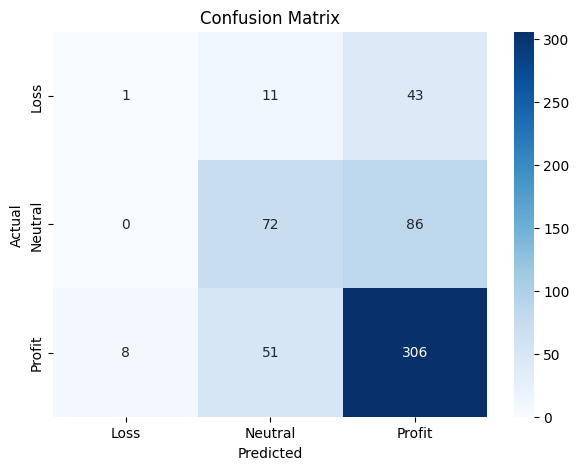

In [77]:
# CONFUSION MATRIX

cm = confusion_matrix(y_test, y_pred)
print(f"Confusion Metrix: {cm}")

plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=rf.classes_,
            yticklabels=rf.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


           Feature  Importance
1     avg_leverage    0.230358
2     avg_position    0.226565
0           trades    0.188398
4  sentiment_value    0.156464
3         win_rate    0.154119
5   classification    0.044095


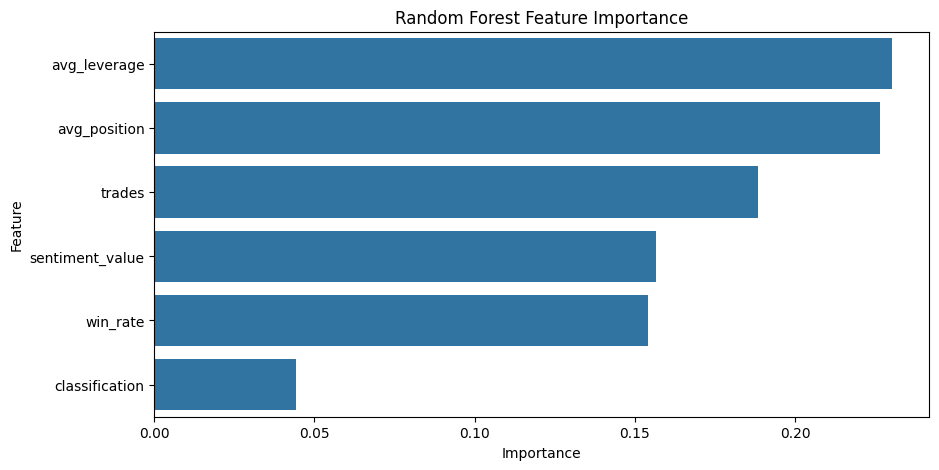

In [71]:
# FEATURE IMPORTANCE

imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print(imp)

plt.figure(figsize=(10,5))
sns.barplot(data=imp, x='Importance', y='Feature')
plt.title("Random Forest Feature Importance")
plt.show()

In [75]:
## Sample Prediction
sample = X_test.copy()
sample['Actual'] = y_test.values
sample['Predicted'] = y_pred
sample.head()

,trades,avg_leverage,avg_position,win_rate,sentiment_value,classification,Actual,Predicted
1891,13,5.060564,290.516154,1.000000,82.0,1,Profit,Profit
488,290,-5.534705,587.659414,0.365517,84.0,1,Profit,Profit
106,112,-2.395135,165.782857,0.535714,78.0,1,Profit,Profit
992,45,6669.829266,19464.353778,0.533333,18.0,0,Neutral,Profit
283,2,-18.272603,116.665000,0.000000,77.0,1,Profit,Profit


**Clustering traders into behavioral archetypes**

In [82]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [83]:
trader = data.groupby('account').agg(
    total_trades=('tradeid', 'count'),
    total_pnl=('closedpnl', 'sum'),
    avg_pnl=('closedpnl', 'mean'),
    win_rate=('win_flag', 'mean'),
    avg_leverage=('leverage', 'mean'),
    avg_position=('sizeusd', 'mean')
).reset_index()

In [84]:
# Fill nulls
trader = trader.fillna(0)

print(trader.head())

                                      account  total_trades     total_pnl  \
0  0x083384f897ee0f19899168e3b1bec365f52a9012          3818  1.600230e+06   
1  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd          7280  4.788532e+04   
2  0x271b280974205ca63b716753467d5a371de622ab          3809 -7.043619e+04   
3  0x28736f43f1e871e6aa8b1148d38d4994275d72c4         13311  1.324648e+05   
4  0x2c229d22b100a7beb69122eed721cee9b24011dd          3239  1.686580e+05   

      avg_pnl  win_rate   avg_leverage  avg_position  
0  419.127768  0.359612     -56.528045  16159.576734  
1    6.577654  0.442720  234004.140959   1653.226327  
2  -18.492043  0.301917   -5470.651490   8893.000898  
3    9.951530  0.438585     895.519175    507.626933  
4   52.071011  0.519914      21.747341   3138.894782  


In [85]:
# FEATURES FOR CLUSTERING
X = trader[['total_trades',
            'total_pnl',
            'avg_pnl',
            'win_rate',
            'avg_leverage',
            'avg_position']]

In [86]:
# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


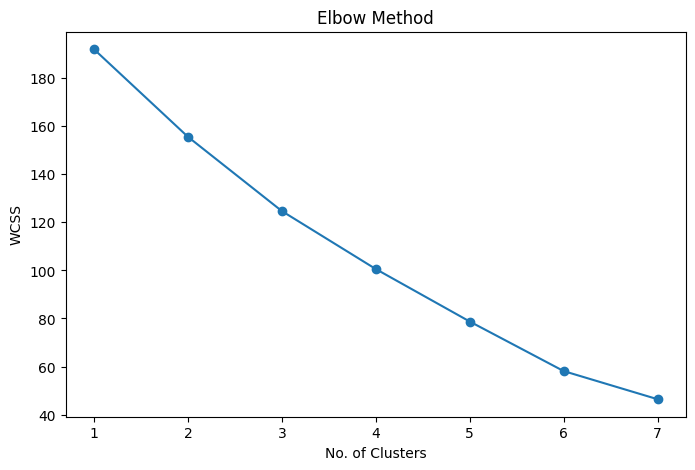

In [87]:
# ELBOW METHOD

wcss = []

for i in range(1, 8):
    km = KMeans(n_clusters=i, random_state=42, n_init=10)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,8), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("No. of Clusters")
plt.ylabel("WCSS")
plt.show()


In [98]:
# FINAL MODEL (3 CLUSTERS)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
trader['Cluster'] = kmeans.fit_predict(X_scaled)
kmeans

KMeans(n_clusters=3, n_init=10, random_state=42)

In [89]:
# CLUSTER SUMMARY

summary = trader.groupby('Cluster').agg(
    Traders=('account','count'),
    Avg_Trades=('total_trades','mean'),
    Avg_PnL=('total_pnl','mean'),
    Win_Rate=('win_rate','mean'),
    Avg_Leverage=('avg_leverage','mean'),
    Avg_Position=('avg_position','mean')
).round(2)

print(summary)

         Traders  Avg_Trades    Avg_PnL  Win_Rate  Avg_Leverage  Avg_Position
Cluster                                                                      
0             24     7284.25  173157.43      0.42    1002740.59       5007.31
1              7     5061.00  861778.50      0.35     -16518.33      10190.22
2              1      975.00  108731.22      0.43   88133972.90        746.73


In [100]:
# LABEL CLUSTERS

cluster_names = {
    0: 'Disciplined Winners',
    1: 'Aggressive Speculators',
    2: 'Casual Traders'
}

trader['Archetype'] = trader['Cluster'].map(cluster_names)
trader.head()

,account,total_trades,total_pnl,avg_pnl,win_rate,avg_leverage,avg_position,Cluster,Archetype,PC1,PC2
0,0x083384f897ee0f19899168e3b1bec365f52a9012,3818,1.600230e+06,419.127768,0.359612,-56.528045,16159.576734,1,Aggressive Speculators,3.324029,-1.759060
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,7280,4.788532e+04,6.577654,0.442720,234004.140959,1653.226327,0,Disciplined Winners,-0.857406,0.681019
2,0x271b280974205ca63b716753467d5a371de622ab,3809,-7.043619e+04,-18.492043,0.301917,-5470.651490,8893.000898,0,Disciplined Winners,-0.629445,-0.126472
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,13311,1.324648e+05,9.951530,0.438585,895.519175,507.626933,0,Disciplined Winners,-0.550174,1.193608
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3239,1.686580e+05,52.071011,0.519914,21.747341,3138.894782,0,Disciplined Winners,-0.721968,0.391547


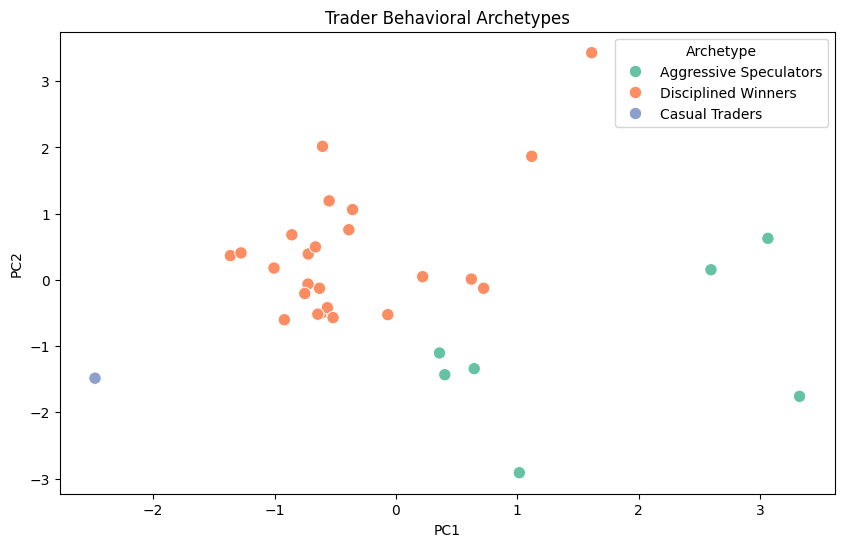

In [91]:
# PCA VISUALIZATION
pca = PCA(n_components=2)
pca_data = pca.fit_transform(X_scaled)

trader['PC1'] = pca_data[:,0]
trader['PC2'] = pca_data[:,1]

plt.figure(figsize=(10,6))
sns.scatterplot(
    data=trader,
    x='PC1',
    y='PC2',
    hue='Archetype',
    palette='Set2',
    s=80
)

plt.title("Trader Behavioral Archetypes")
plt.show()


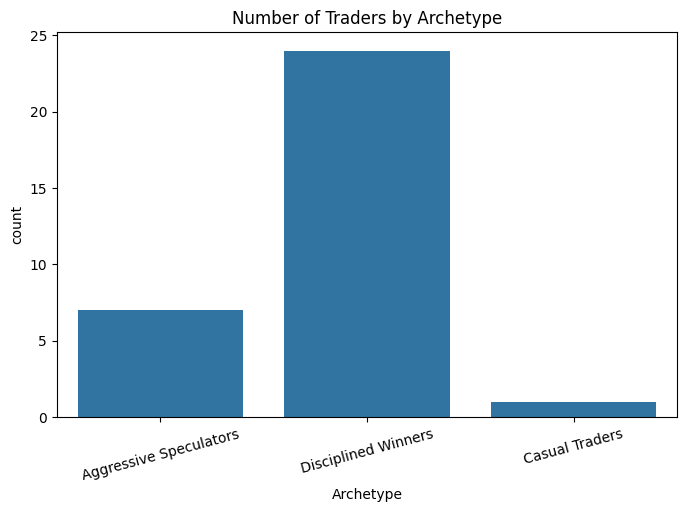

In [92]:
# ARCHETYPE COUNT

plt.figure(figsize=(8,5))
sns.countplot(data=trader, x='Archetype')
plt.title("Number of Traders by Archetype")
plt.xticks(rotation=15)
plt.show()


In [93]:
# EXPORT RESULTS

trader.to_csv("trader_clusters.csv", index=False)

print("Clustering Complete.")
print("File Saved: trader_clusters.csv")

Clustering Complete.
File Saved: trader_clusters.csv
